# ASL CNN Classifier (with Augmentation)

Convolutional network for Sign Language MNIST CSVs in data/asl_data, with data augmentation and metric plots.

In [16]:

from pathlib import Path
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
import matplotlib.pyplot as plt

# Paths and hyperparameters (tuned for better performance)
DATA_DIR = Path("data/asl_data")
TRAIN_CSV = DATA_DIR / "sign_mnist_train.csv"
VALID_CSV = DATA_DIR / "sign_mnist_valid.csv"

hyperparams = {
    "epochs": 20,
    "lr": 3e-4,
    "batch_size": 256,
}

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [17]:

def load_csv_as_tensors(csv_path: Path):
    """Load Sign-MNIST CSV -> (images[B,1,28,28], labels) tensors."""
    df = pd.read_csv(csv_path)
    labels = torch.tensor(df.pop("label").values, dtype=torch.long)
    images = torch.tensor(df.values, dtype=torch.float32) / 255.0
    images = images.view(-1, 1, 28, 28)
    return images, labels

train_x, train_y = load_csv_as_tensors(TRAIN_CSV)
valid_x, valid_y = load_csv_as_tensors(VALID_CSV)
print(f"Train set: {train_x.shape}, Valid set: {valid_x.shape}")


Train set: torch.Size([27455, 1, 28, 28]), Valid set: torch.Size([7172, 1, 28, 28])


In [18]:

class ASLDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Data augmentation tuned for small grayscale digits
train_transform = T.Compose([
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.Normalize((0.5,), (0.5,)),
])

val_transform = T.Compose([
    T.Normalize((0.5,), (0.5,)),
])

train_ds = ASLDataset(train_x, train_y, transform=train_transform)
valid_ds = ASLDataset(valid_x, valid_y, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=hyperparams["batch_size"], shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=hyperparams["batch_size"], shuffle=False)
num_classes = int(torch.unique(train_y).numel())
print(f"Classes: {num_classes}")


Classes: 24


In [19]:

class ASLCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = ASLCNN(num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams["lr"])
print(model)


ASLCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=24, bias=True)
  )
)


In [20]:

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss_sum += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return loss_sum / total, correct / total

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(1, hyperparams["epochs"] + 1):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = loss_sum / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, valid_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")


Epoch 01 | train_loss=2.8376 | train_acc=0.1646 | val_loss=2.2211 | val_acc=0.3008
Epoch 02 | train_loss=2.1171 | train_acc=0.3445 | val_loss=1.6611 | val_acc=0.4792
Epoch 03 | train_loss=1.7609 | train_acc=0.4527 | val_loss=1.4026 | val_acc=0.5620
Epoch 04 | train_loss=1.5031 | train_acc=0.5331 | val_loss=1.2029 | val_acc=0.6097
Epoch 05 | train_loss=1.3076 | train_acc=0.5820 | val_loss=0.9766 | val_acc=0.6741
Epoch 06 | train_loss=1.1635 | train_acc=0.6266 | val_loss=0.9120 | val_acc=0.6919
Epoch 07 | train_loss=1.0329 | train_acc=0.6677 | val_loss=0.7939 | val_acc=0.7263
Epoch 08 | train_loss=0.9406 | train_acc=0.6963 | val_loss=0.7851 | val_acc=0.7259
Epoch 09 | train_loss=0.8720 | train_acc=0.7155 | val_loss=0.6789 | val_acc=0.7653
Epoch 10 | train_loss=0.8134 | train_acc=0.7367 | val_loss=0.6337 | val_acc=0.7692
Epoch 11 | train_loss=0.7420 | train_acc=0.7616 | val_loss=0.5704 | val_acc=0.7966
Epoch 12 | train_loss=0.7082 | train_acc=0.7709 | val_loss=0.5364 | val_acc=0.8120
Epoc

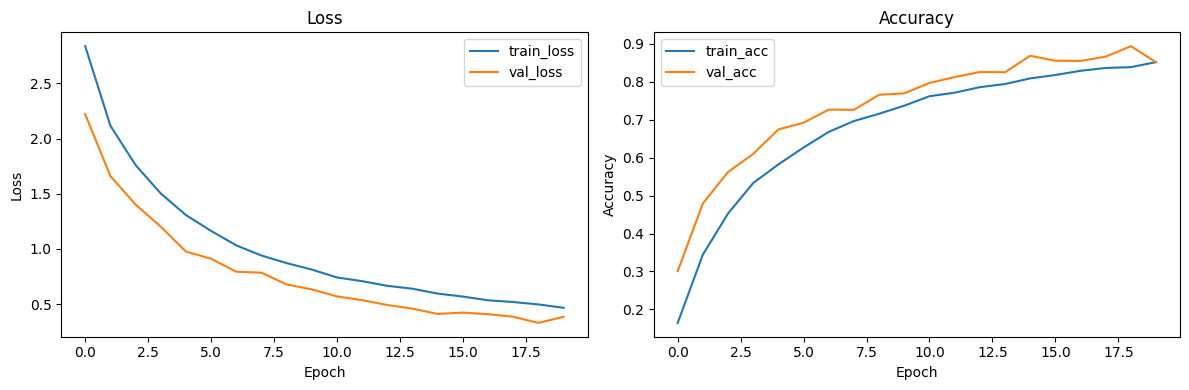

Last epoch -> train_loss: 0.4670, train_acc: 0.8515, val_loss: 0.3852, val_acc: 0.8512


In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train_loss")
axes[0].plot(val_losses, label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train_acc")
axes[1].plot(val_accs, label="val_acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Last epoch -> train_loss: {train_losses[-1]:.4f}, train_acc: {train_accs[-1]:.4f}, val_loss: {val_losses[-1]:.4f}, val_acc: {val_accs[-1]:.4f}")


In [22]:
# Prediction using trained model on CSV data
@torch.no_grad()
def predict_from_csv(model, csv_path: Path):
    """Load CSV and make predictions using trained model."""
    model.eval()
    images, labels = load_csv_as_tensors(csv_path)
    
    # Create dataset and loader for prediction
    pred_ds = ASLDataset(images, labels, transform=val_transform)
    pred_loader = DataLoader(pred_ds, batch_size=hyperparams["batch_size"], shuffle=False)
    
    all_preds = []
    all_labels = []
    
    for batch_images, batch_labels in pred_loader:
        batch_images = batch_images.to(device)
        logits = model(batch_images)
        preds = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_labels.numpy())
    
    return all_preds, all_labels

# Predict on training data
train_preds, train_labels = predict_from_csv(model, TRAIN_CSV)
train_pred_acc = sum(p == l for p, l in zip(train_preds, train_labels)) / len(train_labels)
print(f"Train set predictions - Accuracy: {train_pred_acc:.4f}")

# Predict on validation data
valid_preds, valid_labels = predict_from_csv(model, VALID_CSV)
valid_pred_acc = sum(p == l for p, l in zip(valid_preds, valid_labels)) / len(valid_labels)
print(f"Valid set predictions - Accuracy: {valid_pred_acc:.4f}")

# Show sample predictions
print("\nSample predictions from validation set (first 10):")
for i in range(10):
    print(f"  Sample {i+1}: Predicted={valid_preds[i]}, Actual={valid_labels[i]}")


Train set predictions - Accuracy: 0.9421
Valid set predictions - Accuracy: 0.8512

Sample predictions from validation set (first 10):
  Sample 1: Predicted=6, Actual=6
  Sample 2: Predicted=5, Actual=5
  Sample 3: Predicted=9, Actual=9
  Sample 4: Predicted=0, Actual=0
  Sample 5: Predicted=16, Actual=3
  Sample 6: Predicted=20, Actual=20
  Sample 7: Predicted=9, Actual=9
  Sample 8: Predicted=5, Actual=13
  Sample 9: Predicted=16, Actual=3
  Sample 10: Predicted=7, Actual=7
Valid set predictions - Accuracy: 0.8512

Sample predictions from validation set (first 10):
  Sample 1: Predicted=6, Actual=6
  Sample 2: Predicted=5, Actual=5
  Sample 3: Predicted=9, Actual=9
  Sample 4: Predicted=0, Actual=0
  Sample 5: Predicted=16, Actual=3
  Sample 6: Predicted=20, Actual=20
  Sample 7: Predicted=9, Actual=9
  Sample 8: Predicted=5, Actual=13
  Sample 9: Predicted=16, Actual=3
  Sample 10: Predicted=7, Actual=7


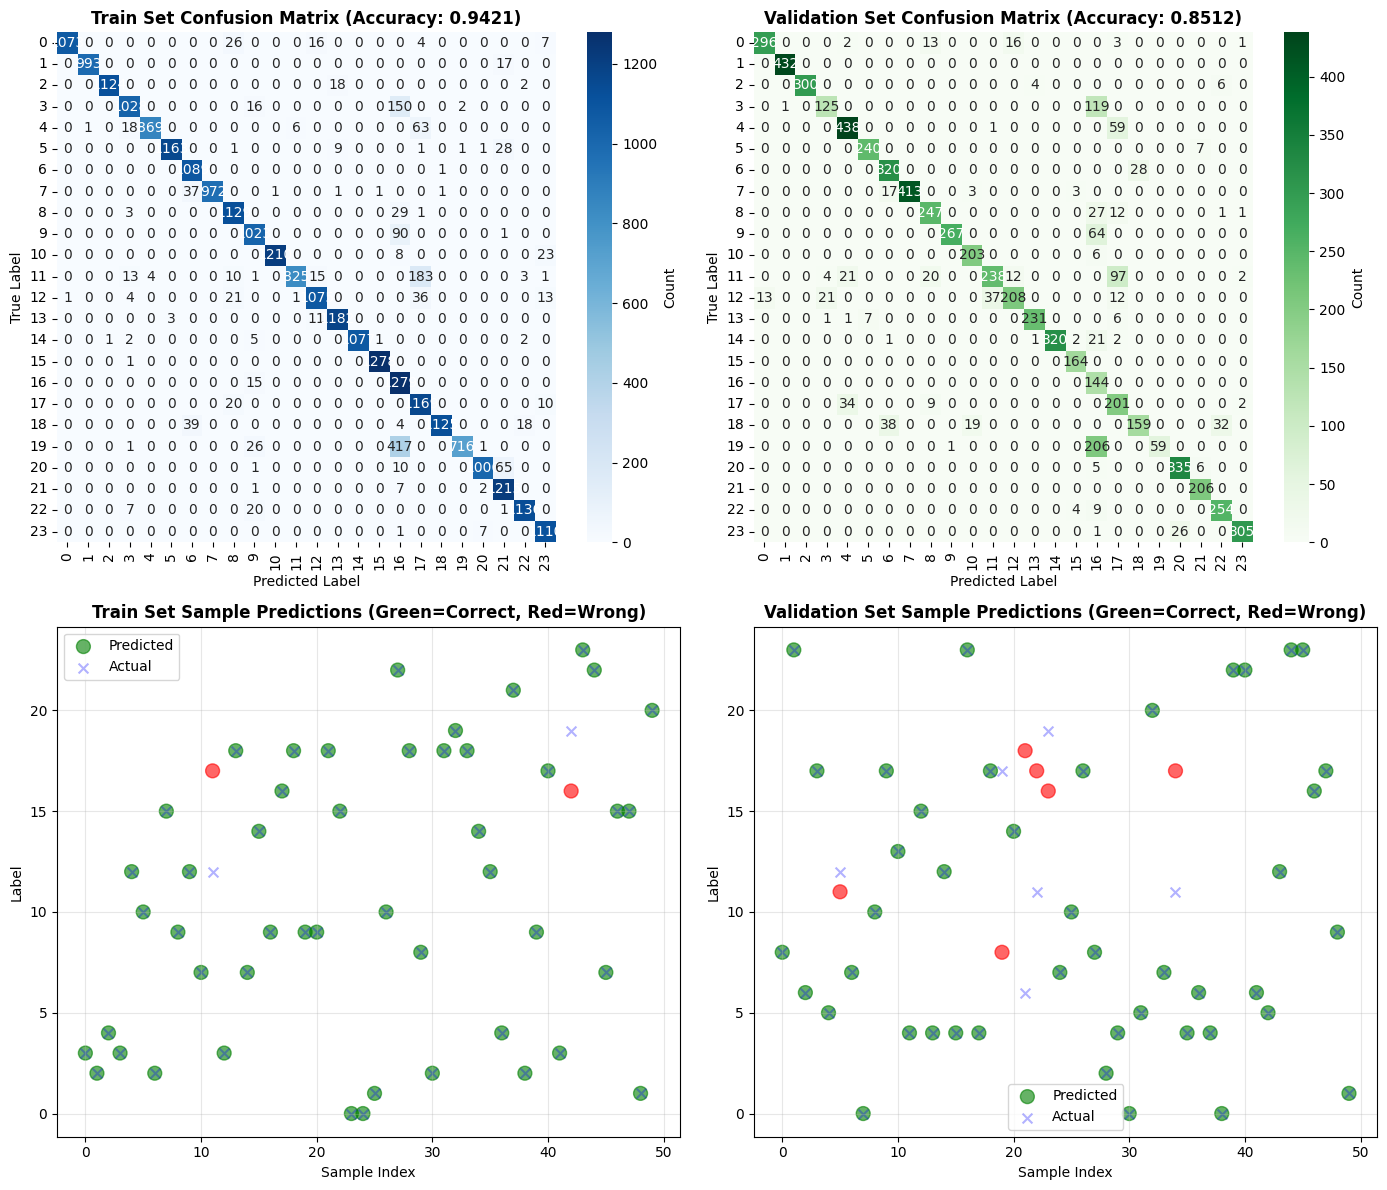


TRAIN SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.95      0.98      1126
           1       1.00      0.98      0.99      1010
           2       1.00      0.98      0.99      1144
           3       0.95      0.86      0.90      1196
           4       1.00      0.91      0.95       957
           5       1.00      0.97      0.98      1204
           6       0.93      1.00      0.97      1090
           7       1.00      0.96      0.98      1013
           8       0.94      0.97      0.95      1162
           9       0.92      0.92      0.92      1114
          10       1.00      0.98      0.99      1241
          11       0.99      0.78      0.87      1055
          12       0.96      0.93      0.95      1151
          13       0.98      0.99      0.98      1196
          14       1.00      0.99      0.99      1088
          15       1.00      1.00      1.00      1279
          16       0.64      0.99      0.78     

In [23]:
# Visualization of predictions
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute confusion matrices
train_cm = confusion_matrix(train_labels, train_preds)
valid_cm = confusion_matrix(valid_labels, valid_preds)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Train set confusion matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title(f'Train Set Confusion Matrix (Accuracy: {train_pred_acc:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# Validation set confusion matrix
sns.heatmap(valid_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], cbar_kws={'label': 'Count'})
axes[0, 1].set_title(f'Validation Set Confusion Matrix (Accuracy: {valid_pred_acc:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# Sample predictions visualization - Train set
sample_size = 50
train_sample_idx = np.random.choice(len(train_preds), sample_size, replace=False)
train_matches = [train_preds[i] == train_labels[i] for i in train_sample_idx]
colors_train = ['green' if match else 'red' for match in train_matches]

axes[1, 0].scatter(range(sample_size), [train_preds[i] for i in train_sample_idx], 
                   color=colors_train, alpha=0.6, s=100, label='Predicted', marker='o')
axes[1, 0].scatter(range(sample_size), [train_labels[i] for i in train_sample_idx], 
                   color='blue', alpha=0.3, s=50, label='Actual', marker='x')
axes[1, 0].set_title(f'Train Set Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Label')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sample predictions visualization - Validation set
valid_sample_idx = np.random.choice(len(valid_preds), sample_size, replace=False)
valid_matches = [valid_preds[i] == valid_labels[i] for i in valid_sample_idx]
colors_valid = ['green' if match else 'red' for match in valid_matches]

axes[1, 1].scatter(range(sample_size), [valid_preds[i] for i in valid_sample_idx], 
                   color=colors_valid, alpha=0.6, s=100, label='Predicted', marker='o')
axes[1, 1].scatter(range(sample_size), [valid_labels[i] for i in valid_sample_idx], 
                   color='blue', alpha=0.3, s=50, label='Actual', marker='x')
axes[1, 1].set_title(f'Validation Set Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Label')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed classification reports
print("\n" + "="*60)
print("TRAIN SET CLASSIFICATION REPORT")
print("="*60)
print(classification_report(train_labels, train_preds))

print("\n" + "="*60)
print("VALIDATION SET CLASSIFICATION REPORT")
print("="*60)
print(classification_report(valid_labels, valid_preds))


Found 2 images in data\asl_image
Image files: ['a.png', 'b.png']



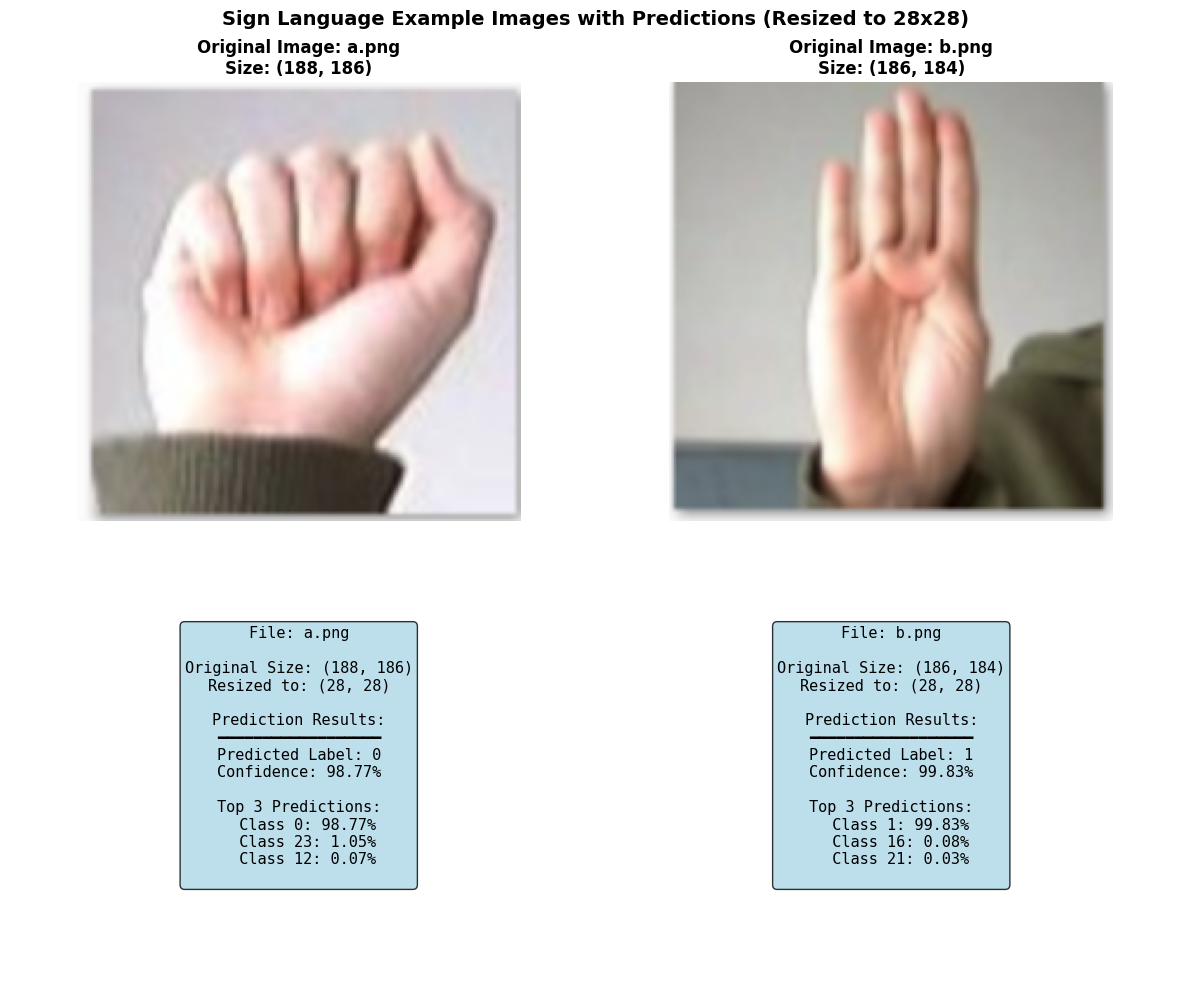

In [26]:
# Display example images from asl_image folder with predictions
from PIL import Image
import os

image_dir = Path("data/asl_image")

# Get all image files
image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

if image_files:
    print(f"Found {len(image_files)} images in {image_dir}")
    print(f"Image files: {image_files}\n")
    
    # Create figure to display all images
    n_images = len(image_files)
    fig, axes = plt.subplots(2, n_images, figsize=(6*n_images, 10))
    
    # Handle single image case
    if n_images == 1:
        axes = axes.reshape(2, 1)
    
    for idx, img_file in enumerate(image_files):
        img_path = image_dir / img_file
        img = Image.open(img_path)
        original_size = img.size
        
        # Display original image
        ax_img = axes[0, idx]
        ax_img.imshow(img)
        ax_img.set_title(f'Original Image: {img_file}\nSize: {original_size}', fontsize=12, fontweight='bold')
        ax_img.axis('off')
        
        # Resize to 28x28 and convert to grayscale
        img_resized = img.convert('L').resize((28, 28), Image.LANCZOS)
        
        # Convert to tensor
        img_array = np.array(img_resized, dtype=np.float32) / 255.0
        img_tensor = torch.tensor(img_array, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1, 1, 28, 28]
        
        # Apply the same normalization used in training
        img_tensor = (img_tensor - 0.5) / 0.5  # Matches val_transform normalization
        
        # Make prediction
        model.eval()
        with torch.no_grad():
            img_tensor_gpu = img_tensor.to(device)
            logits = model(img_tensor_gpu)
            pred = logits.argmax(dim=1).item()
            confidence = torch.softmax(logits, dim=1).max().item()
            # Get all class probabilities
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        
        # Display prediction results as text
        ax_text = axes[1, idx]
        ax_text.axis('off')
        
        # Create text with prediction information
        text_content = f'''File: {img_file}

Original Size: {original_size}
Resized to: (28, 28)

Prediction Results:
━━━━━━━━━━━━━━━━━━
Predicted Label: {pred}
Confidence: {confidence:.2%}

Top 3 Predictions:
{chr(10).join([f"  Class {i}: {probs[i]:.2%}" for i in np.argsort(probs)[-3:][::-1]])}
        '''
        
        ax_text.text(0.5, 0.5, text_content, 
                    fontsize=11, 
                    ha='center', 
                    va='center',
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle('Sign Language Example Images with Predictions (Resized to 28x28)', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print(f"No images found in {image_dir}")
